## **Modelagem Preditiva — Churn em E-commerce**

**Prioridade do negócio:** Maximizar Recall — identificar o máximo de clientes que vão cancelar para permitir intervenção antes do churn acontecer.  
**Métrica de seleção:** F2-Score (Recall com peso 2×).

#### **Pipeline**
```
X_features.csv
    - Split estratificado (80/20)
    - Pipeline: StandardScaler + SMOTE (apenas treino) + Modelo
    - Modelos: LR (baseline), Random Forest, XGBoost, LightGBM
    - Threshold otimizado por F2-Score
    - Avaliação final + Segmentação de risco
```

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection     import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing       import StandardScaler
from sklearn.pipeline            import Pipeline
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier
from sklearn.metrics             import (
    recall_score, precision_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
from imblearn.over_sampling      import SMOTE
from imblearn.pipeline           import Pipeline as ImbPipeline
from xgboost                     import XGBClassifier
import lightgbm as lgb

DATA_PROC   = Path('../data/processed')
FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
COR_CHURN    = '#E74C3C'
COR_OK       = '#2ECC71'
COR_ACCENT   = '#2980B9'
COR_RF       = '#F39C12'
COR_XGB      = '#8E44AD'
COR_LGBM     = '#16A085'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def save_fig(name):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')
    plt.show()
    plt.close()

## **Carregar Dados e Split:**

In [2]:
X = pd.read_csv(DATA_PROC / 'X_features.csv')
y = pd.read_csv(DATA_PROC / 'y_target.csv').squeeze()

print(f'X: {X.shape} | Taxa de churn: {y.mean():.2%}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape} | Churn: {y_train.mean():.2%}')
print(f'Teste : {X_test.shape}  | Churn: {y_test.mean():.2%}')

X: (10000, 29) | Taxa de churn: 22.26%
Treino: (8000, 29) | Churn: 22.26%
Teste : (2000, 29)  | Churn: 22.25%


## **Funções Auxiliares:**

In [10]:
def threshold_otimo_f2(y_true, y_proba) -> float:
    """
    Retorna o threshold que maximiza F2-Score.
    F2 penaliza falsos negativos (clientes de churn perdidos) 2× mais.
    """
    prec, rec, thrs = precision_recall_curve(y_true, y_proba)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-9)
    idx = np.argmax(f2[:-1])
    return float(thrs[idx])


def avaliar(y_true, y_pred, y_proba, nome: str) -> dict:
    """Calcula e imprime métricas. Retorna dict para comparação."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    rec    = recall_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred)
    f2     = fbeta_score(y_true, y_pred, beta=2)
    auc    = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    print(f'\n{"─"*52}')
    print(f'  {nome}')
    print(f'{"─"*52}')
    print(f'  Recall    : {rec:.4f} prioridade')
    print(f'  Precisão  : {prec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  F2-Score  : {f2:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  PR-AUC    : {pr_auc:.4f}')
    print(f'  FN (clientes perdidos)  : {fn}')
    print(f'  FP (falsos alertas)     : {fp}')

    return dict(nome=nome, recall=rec, precision=prec, f1=f1, f2=f2,
                auc=auc, pr_auc=pr_auc, fn=fn, fp=fp, tp=tp, tn=tn,
                y_pred=y_pred, y_proba=y_proba)


print('Funções de avaliação definidas')

Funções de avaliação definidas


## **Pipelines com SMOTE:**

In [8]:
# Construir pipelines: scaler > SMOTE > modelo
pipelines = {
    'Logistic Regression': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                      class_weight='balanced', n_jobs=-1)),
    ]),
    'Random Forest': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    RandomForestClassifier(n_estimators=300, max_depth=15,
                                          min_samples_leaf=5,
                                          class_weight='balanced',
                                          random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    'XGBoost': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    XGBClassifier(n_estimators=300, learning_rate=0.05,
                                  max_depth=6, subsample=0.8,
                                  colsample_bytree=0.8, reg_alpha=0.1,
                                  scale_pos_weight=4,
                                  eval_metric='logloss',
                                  random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

pipelines['LightGBM'] = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE)),
    ('clf',    lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=7, num_leaves=63,
                                     min_child_samples=20, subsample=0.8,
                                     colsample_bytree=0.8, reg_alpha=0.1,
                                     scale_pos_weight=4,
                                      random_state=RANDOM_STATE, n_jobs=-1,
                                      verbose=-1)),
    ])

print(f'Pipelines criados: {list(pipelines.keys())}')

Pipelines criados: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


## **Treinamento e Avaliação:**

In [9]:
modelos_treinados = {}
thresholds        = {}
todos_resultados  = []

for nome, pipe in pipelines.items():
    print(f'\nTreinando: {nome}...')
    pipe.fit(X_train, y_train)
    modelos_treinados[nome] = pipe

    y_proba = pipe.predict_proba(X_test)[:, 1]
    thr     = threshold_otimo_f2(y_test, y_proba)
    y_pred  = (y_proba >= thr).astype(int)
    thresholds[nome] = thr

    res = avaliar(y_test, y_pred, y_proba, f'{nome} (thr={thr:.3f})')
    res['threshold'] = thr
    todos_resultados.append(res)


Treinando: Logistic Regression...

────────────────────────────────────────────────────
  Logistic Regression (thr=0.344)
────────────────────────────────────────────────────
  Recall    : 0.8966  ← prioridade
  Precisão  : 0.2991
  F1-Score  : 0.4486
  F2-Score  : 0.6407
  AUC-ROC   : 0.7379
  PR-AUC    : 0.4440
  FN (clientes perdidos)  : 46
  FP (falsos alertas)     : 935

Treinando: Random Forest...

────────────────────────────────────────────────────
  Random Forest (thr=0.262)
────────────────────────────────────────────────────
  Recall    : 0.8674  ← prioridade
  Precisão  : 0.3174
  F1-Score  : 0.4648
  F2-Score  : 0.6442
  AUC-ROC   : 0.7253
  PR-AUC    : 0.4269
  FN (clientes perdidos)  : 59
  FP (falsos alertas)     : 830

Treinando: XGBoost...

────────────────────────────────────────────────────
  XGBoost (thr=0.372)
────────────────────────────────────────────────────
  Recall    : 0.8360  ← prioridade
  Precisão  : 0.3263
  F1-Score  : 0.4694
  F2-Score  : 0.6370
  AU

---
## 5 · Tabela Comparativa

In [12]:
df_res = pd.DataFrame([{
    'Modelo'    : r['nome'].split('(')[0].strip(),
    'Threshold' : round(r['threshold'], 3),
    'Recall'    : round(r['recall'], 4),
    'Precisão'  : round(r['precision'], 4),
    'F1-Score'  : round(r['f1'], 4),
    'F2-Score'  : round(r['f2'], 4),
    'AUC-ROC'   : round(r['auc'], 4),
    'PR-AUC'    : round(r['pr_auc'], 4),
    'FN'        : r['fn'],
    'FP'        : r['fp'],
} for r in todos_resultados]).sort_values('F2-Score', ascending=False)

print('Comparação Final dos Modelos')
print(df_res.to_string(index=False))

df_res.to_csv(MODELS_DIR / 'resultados_modelos.csv', index=False)
print('\nResultados salvos')

Comparação Final dos Modelos
             Modelo  Threshold  Recall  Precisão  F1-Score  F2-Score  AUC-ROC  PR-AUC  FN  FP
      Random Forest      0.262  0.8674    0.3174    0.4648    0.6442   0.7253  0.4269  59 830
Logistic Regression      0.344  0.8966    0.2991    0.4486    0.6407   0.7379  0.4440  46 935
            XGBoost      0.372  0.8360    0.3263    0.4694    0.6370   0.7153  0.4178  73 768
           LightGBM      0.272  0.8629    0.3040    0.4496    0.6310   0.7139  0.4123  61 879

Resultados salvos


## **Gráfico Comparativo de Métricas:**

Salvo: ..\figures\07_comparacao_modelos.png


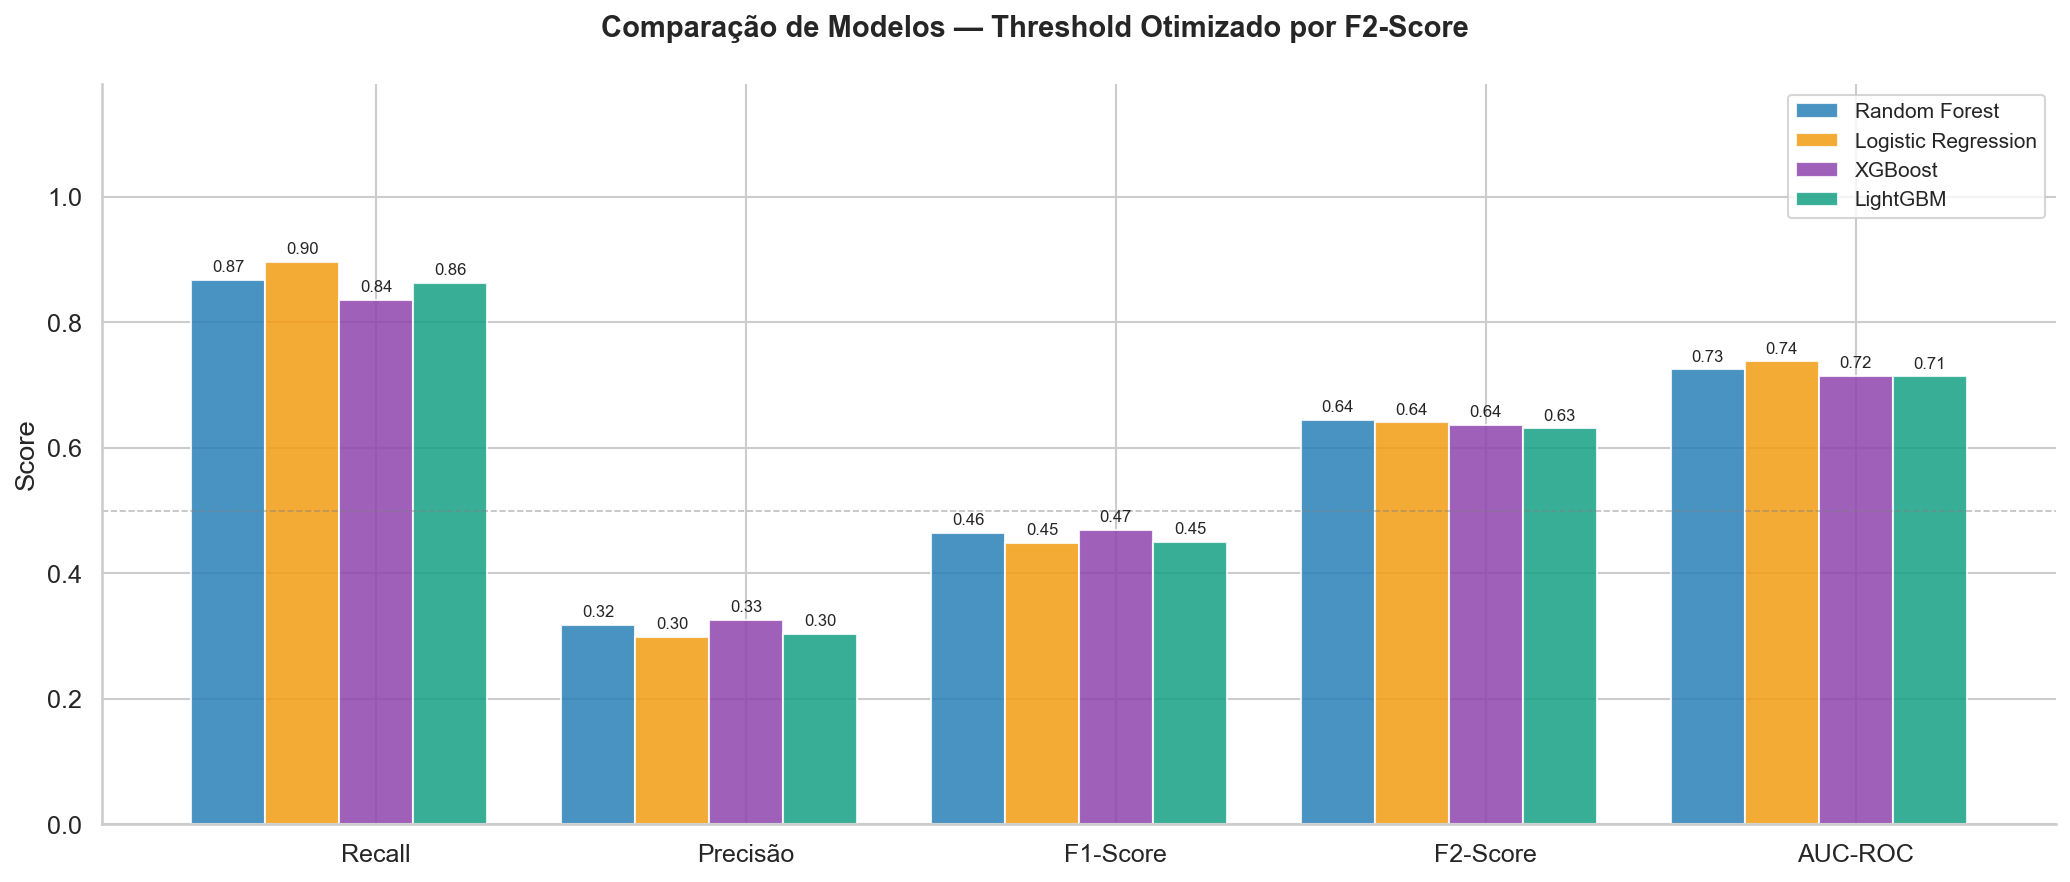

In [13]:
metricas_plot = ['Recall', 'Precisão', 'F1-Score', 'F2-Score', 'AUC-ROC']
nomes_mod     = df_res['Modelo'].tolist()
cores_mod     = [COR_ACCENT, COR_RF, COR_XGB, COR_LGBM][:len(nomes_mod)]
x = np.arange(len(metricas_plot))
w = 0.80 / len(nomes_mod)

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Comparação de Modelos — Threshold Otimizado por F2-Score',
             fontsize=14, fontweight='bold')

for i, (nome, cor) in enumerate(zip(nomes_mod, cores_mod)):
    vals = df_res[df_res['Modelo'] == nome][metricas_plot].values[0]
    bars = ax.bar(x + i*w - w*len(nomes_mod)/2, vals, w,
                  label=nome, color=cor, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
save_fig('07_comparacao_modelos')

## **Curvas Precision-Recall e ROC:**

Salvo: ..\figures\08_curvas_pr_roc.png


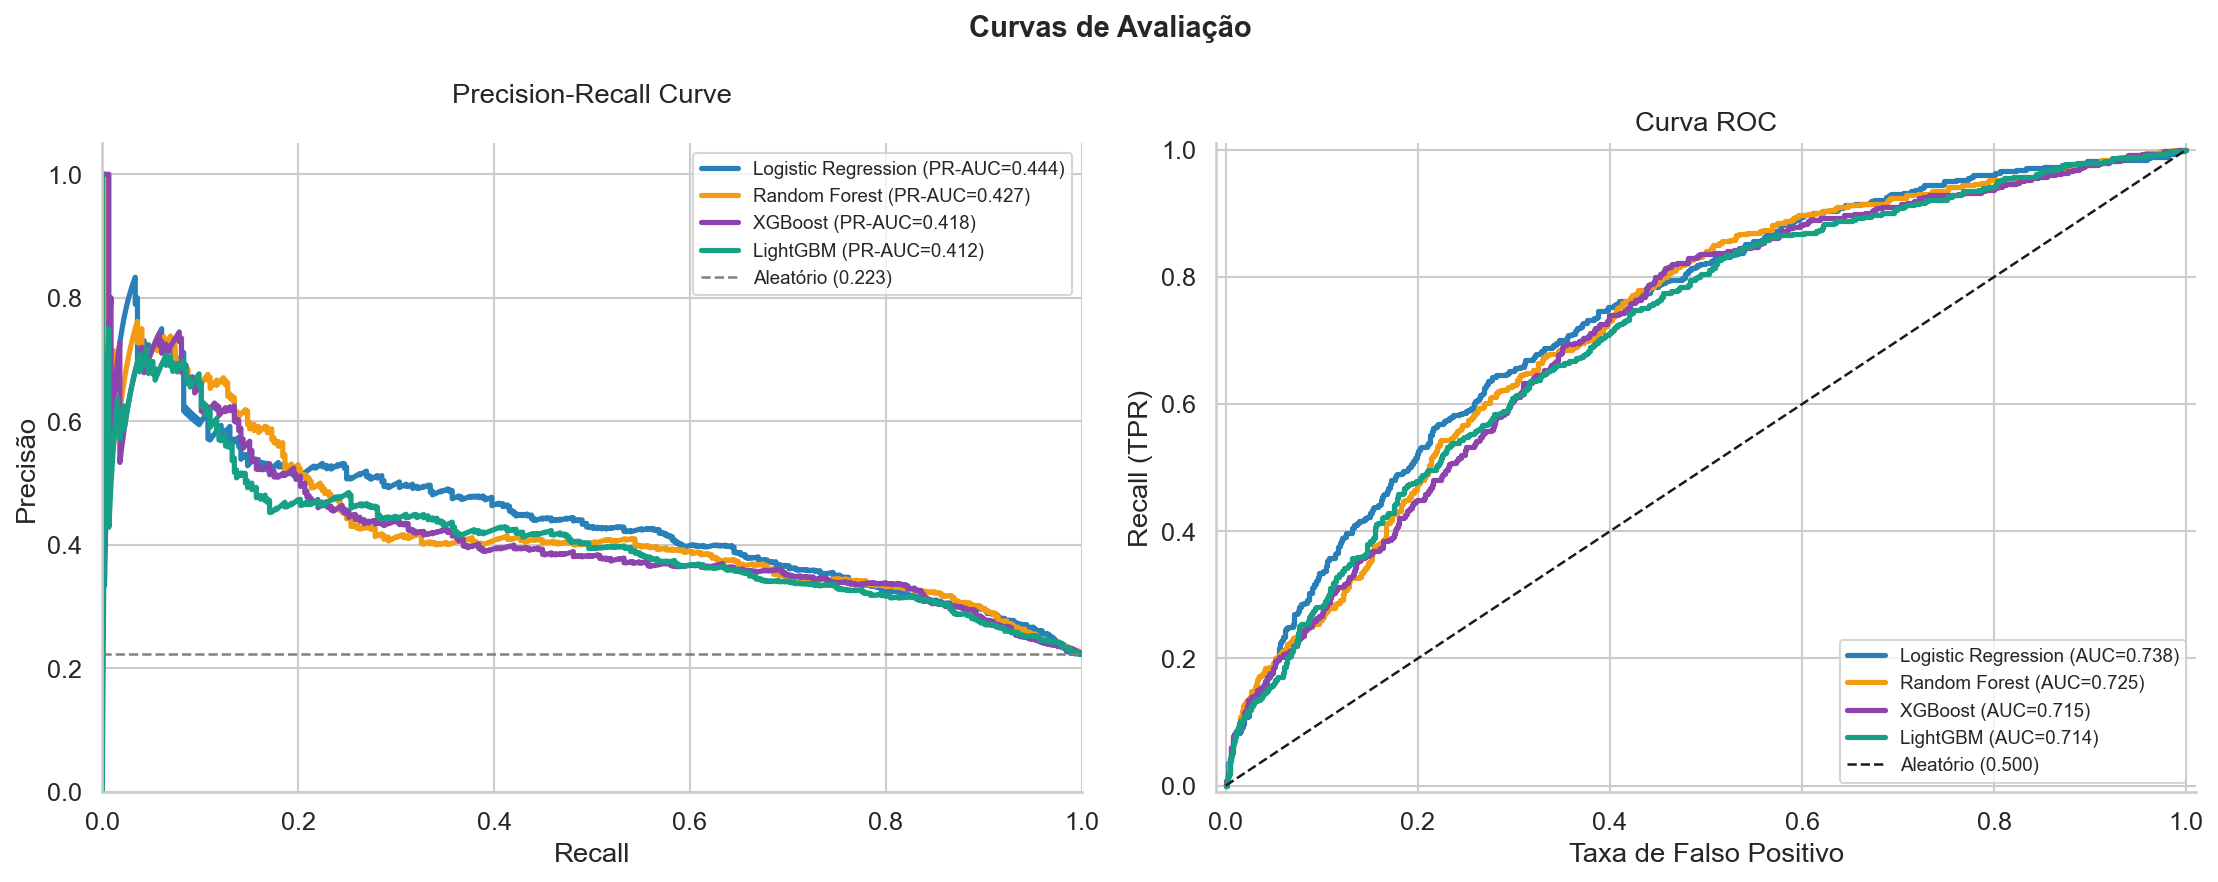

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Curvas de Avaliação', fontsize=14, fontweight='bold')

ax = axes[0]
baseline_pr = y_test.mean()
for res, cor in zip(todos_resultados, cores_mod):
    prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_proba'])
    nome = res['nome'].split('(')[0].strip()
    ax.plot(rec_c, prec_c, color=cor, linewidth=2.5,
            label=f'{nome} (PR-AUC={res["pr_auc"]:.3f})')
ax.axhline(baseline_pr, color='gray', linestyle='--', linewidth=1.2,
           label=f'Aleatório ({baseline_pr:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisão')
ax.set_title('Precision-Recall Curve\n')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

ax = axes[1]
for res, cor in zip(todos_resultados, cores_mod):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    nome = res['nome'].split('(')[0].strip()
    ax.plot(fpr, tpr, color=cor, linewidth=2.5,
            label=f'{nome} (AUC={res["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=1.2, label='Aleatório (0.500)')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Recall (TPR)')
ax.set_title('Curva ROC')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([-0.01,1.01]); ax.set_ylim([-0.01,1.01])

plt.tight_layout()
save_fig('08_curvas_pr_roc')

## **Matrizes de Confusão:**

Salvo: ..\figures\09_matrizes_confusao.png


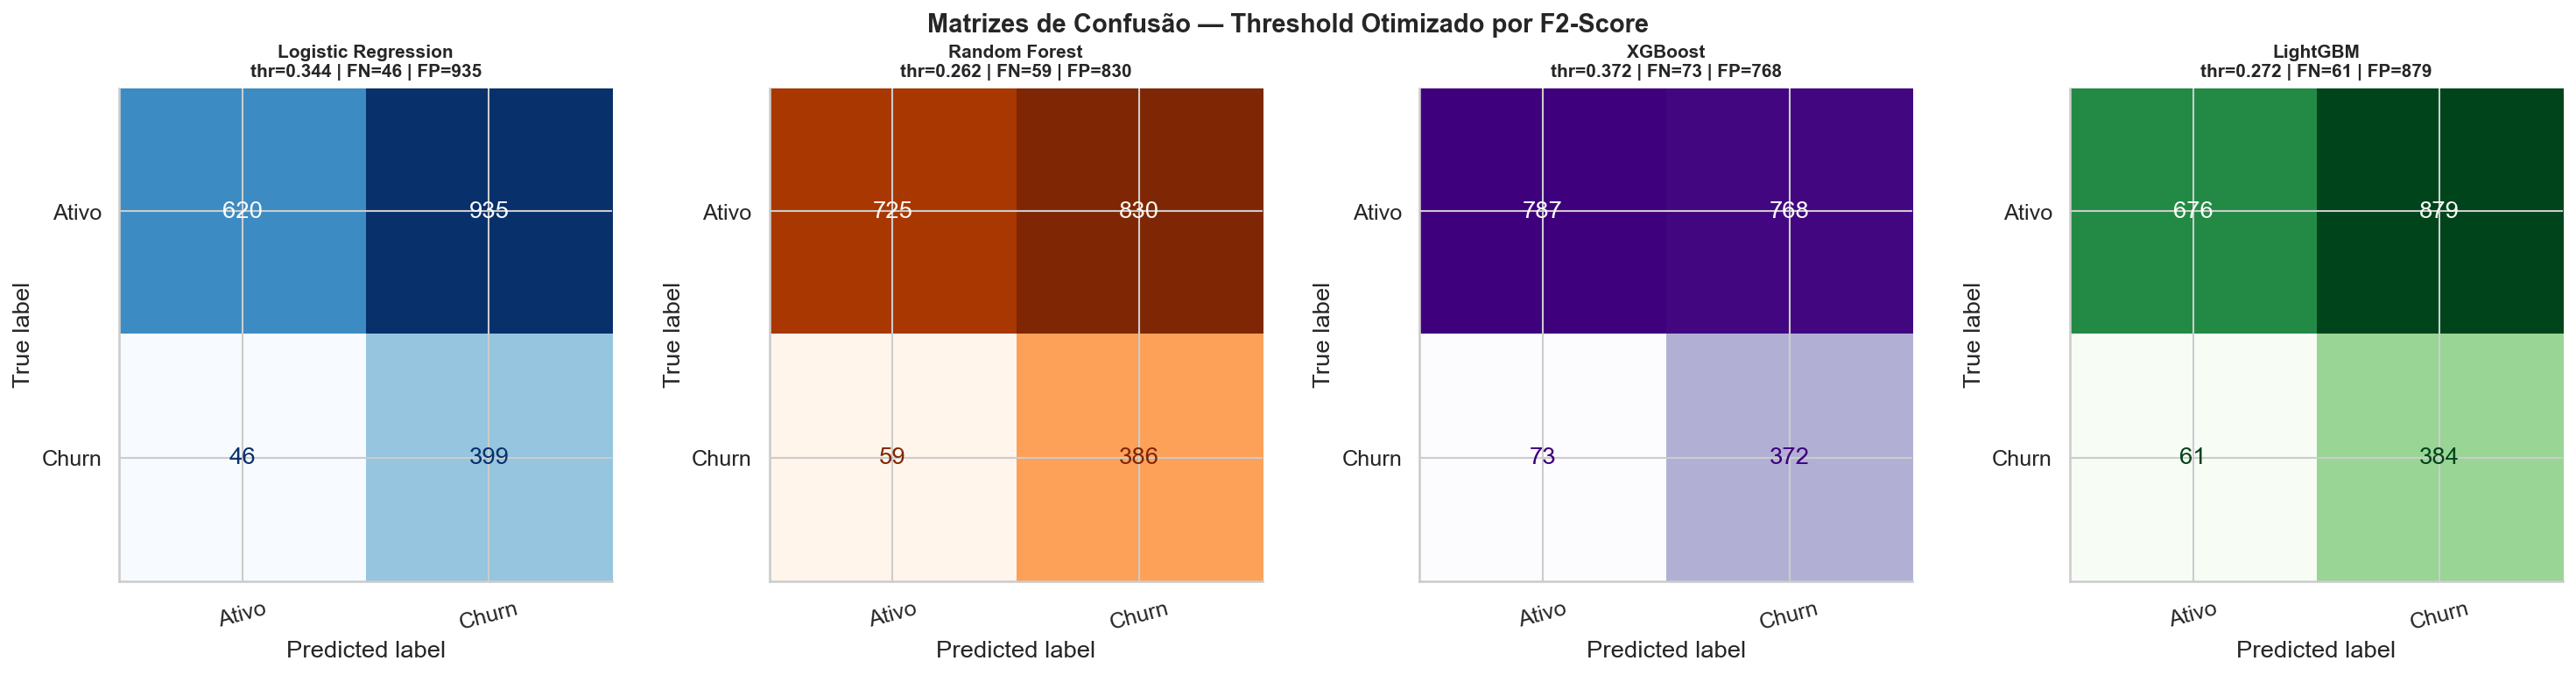

In [15]:
n = len(todos_resultados)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]
fig.suptitle('Matrizes de Confusão — Threshold Otimizado por F2-Score',
             fontsize=14, fontweight='bold')

cmaps = ['Blues','Oranges','Purples','Greens']
for ax, res, cmap in zip(axes, todos_resultados, cmaps):
    cm   = confusion_matrix(y_test, res['y_pred'])
    nome = res['nome'].split('(')[0].strip()
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ativo','Churn'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')
    ax.set_title(f'{nome}\nthr={res["threshold"]:.3f} | FN={res["fn"]} | FP={res["fp"]}',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
save_fig('09_matrizes_confusao')

## **Feature Importance:**

Salvo: ..\figures\10_feature_importance.png


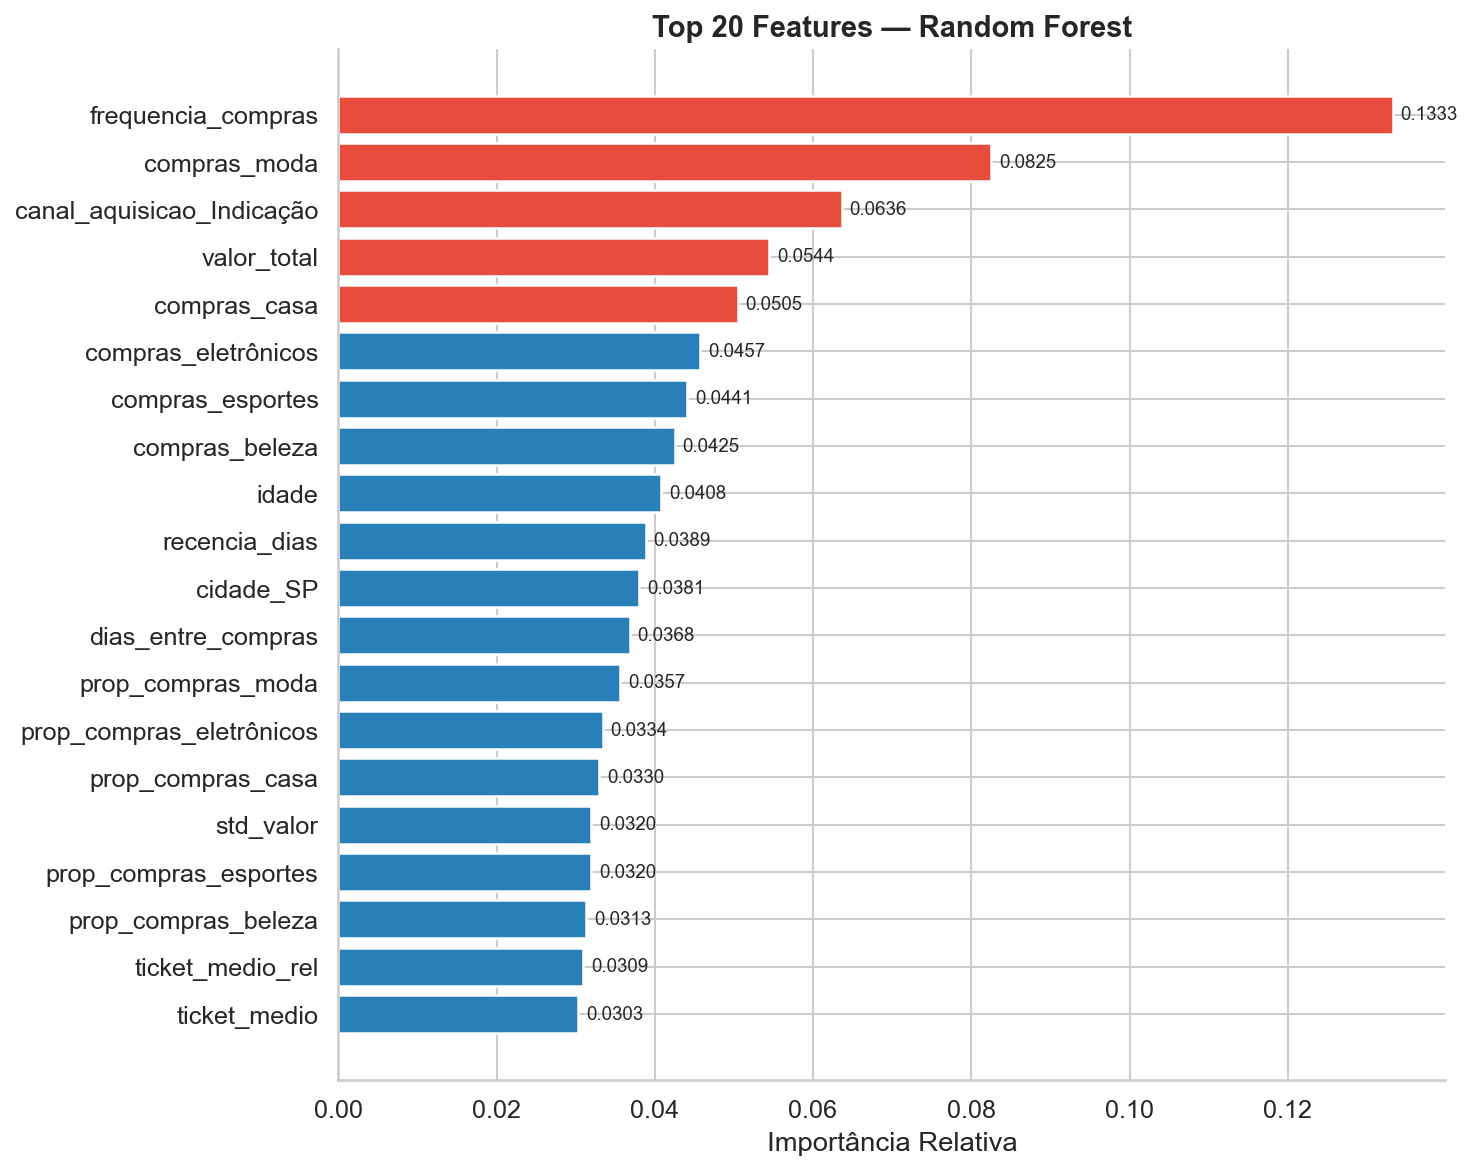


Feature importance salva | Modelo: Random Forest


In [16]:
# Usar o melhor modelo por F2-Score
melhor_nome = df_res.iloc[0]['Modelo']
melhor_pipe = modelos_treinados[melhor_nome]
clf         = melhor_pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importancias = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importancias = np.abs(clf.coef_[0])
else:
    importancias = np.zeros(X.shape[1])

fi = pd.DataFrame({'Feature': X.columns, 'Importância': importancias})\
     .sort_values('Importância', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title(f'Top 20 Features — {melhor_nome}', fontsize=14, fontweight='bold')
cores_fi = [COR_CHURN if v >= fi['Importância'].quantile(0.75) else COR_ACCENT
            for v in fi['Importância']]
bars = ax.barh(fi['Feature'], fi['Importância'],
               color=cores_fi, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, fi['Importância']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importância Relativa')
ax.invert_yaxis()

plt.tight_layout()
save_fig('10_feature_importance')

fi.to_csv(MODELS_DIR / 'feature_importance.csv', index=False)
print(f'\nFeature importance salva | Modelo: {melhor_nome}')

## **Salvar Modelo Final:**

In [17]:
thr_final = thresholds[melhor_nome]

joblib.dump(melhor_pipe, MODELS_DIR / 'pipeline_final.pkl')
joblib.dump(thr_final,   MODELS_DIR / 'threshold_final.pkl')
df_res.to_csv(MODELS_DIR / 'resultados_modelos.csv', index=False)

melhor = df_res.iloc[0]
print(f"""
╔══════════════════════════════════════════════════════╗
║            MODELO FINAL SALVO                        ║
╠══════════════════════════════════════════════════════╣
║  Modelo    : {melhor['Modelo']:<38}║
║  Threshold : {melhor['Threshold']:<38}║
╠══════════════════════════════════════════════════════╣
║  Recall    : {melhor['Recall']:<38}║
║  Precisão  : {melhor['Precisão']:<38}║
║  F2-Score  : {melhor['F2-Score']:<38}║
║  AUC-ROC   : {melhor['AUC-ROC']:<38}║
║  PR-AUC    : {melhor['PR-AUC']:<38}║
║  FN        : {melhor['FN']:<38}║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║            MODELO FINAL SALVO                        ║
╠══════════════════════════════════════════════════════╣
║  Modelo    : Random Forest                         ║
║  Threshold : 0.262                                 ║
╠══════════════════════════════════════════════════════╣
║  Recall    : 0.8674                                ║
║  Precisão  : 0.3174                                ║
║  F2-Score  : 0.6442                                ║
║  AUC-ROC   : 0.7253                                ║
║  PR-AUC    : 0.4269                                ║
║  FN        : 59                                    ║
╚══════════════════════════════════════════════════════╝



## **Segmentação de Risco:**

In [20]:
df_clientes = pd.read_csv(DATA_PROC / 'clientes_com_features.csv')

# Score de churn para todos os clientes
df_clientes['score_churn'] = melhor_pipe.predict_proba(X)[:, 1]

df_clientes['segmento'] = pd.cut(
    df_clientes['score_churn'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Crítico']
)

segmentos = df_clientes['segmento'].value_counts().sort_index()
churn_real_seg = df_clientes.groupby('segmento', observed=True)['churn'].mean() * 100

print('Distribuição dos Segmentos:')
for seg in ['Muito Baixo','Baixo','Médio','Alto','Crítico']:
    if seg in segmentos.index:
        n   = segmentos[seg]
        pct = n / len(df_clientes) * 100
        cr  = churn_real_seg.get(seg, 0)
        print(f'  {seg:<12}: {n:>5,} clientes ({pct:.1f}%) | Churn real: {cr:.1f}%')

# Salvar
df_clientes.to_csv(DATA_PROC / 'clientes_segmentados.csv', index=False)
print('\nSegmentação salva em data/processed/clientes_segmentados.csv')

Distribuição dos Segmentos:
  Muito Baixo : 3,446 clientes (34.5%) | Churn real: 1.3%
  Baixo       : 3,193 clientes (31.9%) | Churn real: 7.6%
  Médio       : 2,490 clientes (24.9%) | Churn real: 45.8%
  Alto        :   757 clientes (7.6%) | Churn real: 91.0%
  Crítico     :   114 clientes (1.1%) | Churn real: 94.7%

Segmentação salva em data/processed/clientes_segmentados.csv


## **Impacto de Negócio Estimado:**

In [21]:
# Premissas
TICKET_MEDIO        = 172.0   # R$ — ticket médio estimado
CICLO_ANUAL         = 4       # compras por cliente por ano
TAXA_SUCESSO        = 0.35    # 35% dos abordados retidos
CUSTO_POR_CLIENTE   = {'Muito Baixo':5, 'Baixo':10, 'Médio':25, 'Alto':50, 'Crítico':80}

receita_retida = 0
custo_total    = 0

print('ANÁLISE DE IMPACTO FINANCEIRO:')
print(f'  Ticket médio: R$ {TICKET_MEDIO:.2f} | Ciclo anual: {CICLO_ANUAL} compras')
print(f'  Taxa de sucesso das ações: {TAXA_SUCESSO:.0%}\n')

for seg in ['Muito Baixo','Baixo','Médio','Alto','Crítico']:
    if seg not in segmentos.index:
        continue
    n_seg      = segmentos[seg]
    churn_seg  = churn_real_seg.get(seg, 0) / 100
    n_churn    = int(n_seg * churn_seg)
    n_retidos  = int(n_churn * TAXA_SUCESSO)
    receita    = n_retidos * TICKET_MEDIO * CICLO_ANUAL
    custo      = n_seg * CUSTO_POR_CLIENTE[seg]
    receita_retida += receita
    custo_total    += custo
    print(f'  {seg:<12}: {n_churn:>4} em risco | {n_retidos:>3} retidos | '
          f'Receita: R${receita:>10,.0f} | Custo: R${custo:>8,.0f}')

lucro_liquido = receita_retida - custo_total
roi           = receita_retida / custo_total if custo_total > 0 else 0

print(f"""
╔══════════════════════════════════════════════════════╗
║  Receita total retida : R$ {receita_retida:>12,.2f}          ║
║  Custo total ações    : R$ {custo_total:>12,.2f}          ║
║  Lucro líquido        : R$ {lucro_liquido:>12,.2f}          ║
║  ROI estimado         : {roi:.1f}x                         ║
╚══════════════════════════════════════════════════════╝
""")

ANÁLISE DE IMPACTO FINANCEIRO:
  Ticket médio: R$ 172.00 | Ciclo anual: 4 compras
  Taxa de sucesso das ações: 35%

  Muito Baixo :   44 em risco |  15 retidos | Receita: R$    10,320 | Custo: R$  17,230
  Baixo       :  244 em risco |  85 retidos | Receita: R$    58,480 | Custo: R$  31,930
  Médio       : 1141 em risco | 399 retidos | Receita: R$   274,512 | Custo: R$  62,250
  Alto        :  689 em risco | 241 retidos | Receita: R$   165,808 | Custo: R$  37,850
  Crítico     :  108 em risco |  37 retidos | Receita: R$    25,456 | Custo: R$   9,120

╔══════════════════════════════════════════════════════╗
║  Receita total retida : R$   534,576.00          ║
║  Custo total ações    : R$   158,380.00          ║
║  Lucro líquido        : R$   376,196.00          ║
║  ROI estimado         : 3.4x                         ║
╚══════════════════════════════════════════════════════╝

